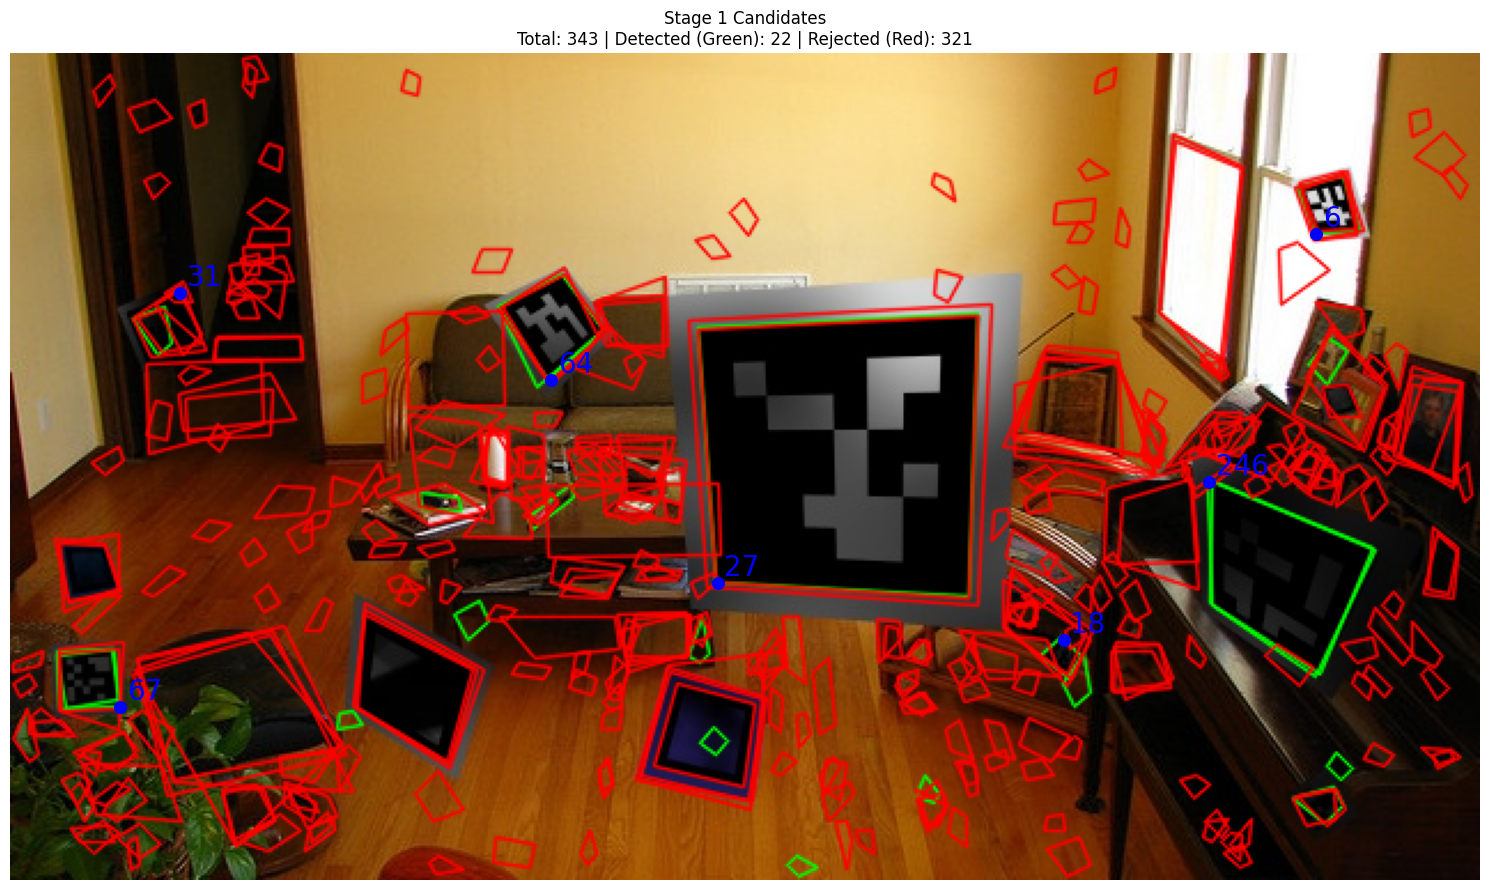

In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd

def visualize_stage1_candidates(csv_path, image_bgr, candidates, target_image_id,  figsize=(15, 10)):
    """
    Vẽ toàn bộ candidates tìm được lên ảnh gốc.
    - Màu Xanh lá (Detected): OpenCV nhận diện được mã.
    - Màu Đỏ (Rejected): Vùng tiềm năng nhưng không giải mã được.
    """
    
    df = pd.read_csv(csv_path)
    cf = pd.read_csv(csv_path, dtype={"image_id": str})

    # Tìm dòng tương ứng
    row = df[cf["image_id"] == target_image_id]

    if row.empty:
        print(f"Không tìm thấy image_id = {target_image_id}")
        return

    prediction_string = row.iloc[0]["prediction_string"]

    if pd.isna(prediction_string) or prediction_string.strip() == "":
        print("prediction_string rỗng")
        return

    # Parse prediction_string
    values = prediction_string.strip().split()

    if len(values) % 3 != 0:
        print("prediction_string không đúng format id x y")
        return

    points = []

    for i in range(0, len(values), 3):
        class_id = int(values[i])
        x = float(values[i + 1])
        y = float(values[i + 2])

        points.append((class_id, x, y))


    vis_img = image_bgr.copy()
    num_detected = 0
    num_rejected = 0
    
    for cand in candidates:
        # Chuyển corners sang định dạng int để vẽ
        pts = np.int32(cand["corners"]).reshape((-1, 1, 2))
        
        # Phân loại để chọn màu và độ dày
        if cand.get("type") == "detected":
            color = (0, 255, 0)  # Xanh lá
            thickness = 1
            num_detected += 1
            # Vẽ đa giác bao quanh candidate
            #cv2.polylines(vis_img, [pts], isClosed=True, color=color, thickness=thickness, lineType=cv2.LINE_AA)
            
            # Vẽ một chấm nhỏ tại góc đầu tiên (Top-Left) để xác định định hướng
            top_left = tuple(pts[0][0])
            #cv2.circle(vis_img, top_left, 4, (255, 255, 255), -1) # Chấm trắng nhỏ làm tâm
            #cv2.circle(vis_img, top_left, 2, color, -1)           # Chấm màu theo loại
        else:
            color = (0, 0, 255)  # Đỏ
            thickness = 1
            num_rejected += 1
            
        cv2.polylines(vis_img, [pts], isClosed=True, color=color, thickness=thickness, lineType=cv2.LINE_AA)
        
    # Chuyển màu để hiển thị đúng trên Matplotlib
    vis_rgb = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=figsize)
    plt.imshow(vis_rgb)
    
    # Tiêu đề chi tiết để debug
    plt.title(f"Stage 1 Candidates\n"
              f"Total: {len(candidates)} | "
              f"Detected (Green): {num_detected} | "
              f"Rejected (Red): {num_rejected}")
    
    for class_id, x, y in points:
        plt.scatter(x, y, s=70, color='blue')
        plt.text(
            x + 3,
            y - 3,
            str(class_id),
            fontsize=20,
            color='blue'
        )
    
    plt.axis("off")
    plt.tight_layout()
    plt.show()


from src.preprocess import generate_augmented_images
from src.detector import extract_candidates, filter_and_cluster_candidates

img = cv2.imread("data/aruco_data/train/000000002270.jpg")
img_name = "000000002270"
aug_dict = generate_augmented_images(img)
candidates = extract_candidates(img, aug_dict)
final_can = filter_and_cluster_candidates(candidates)
visualize_stage1_candidates("data/train.csv", img, final_can, img_name)

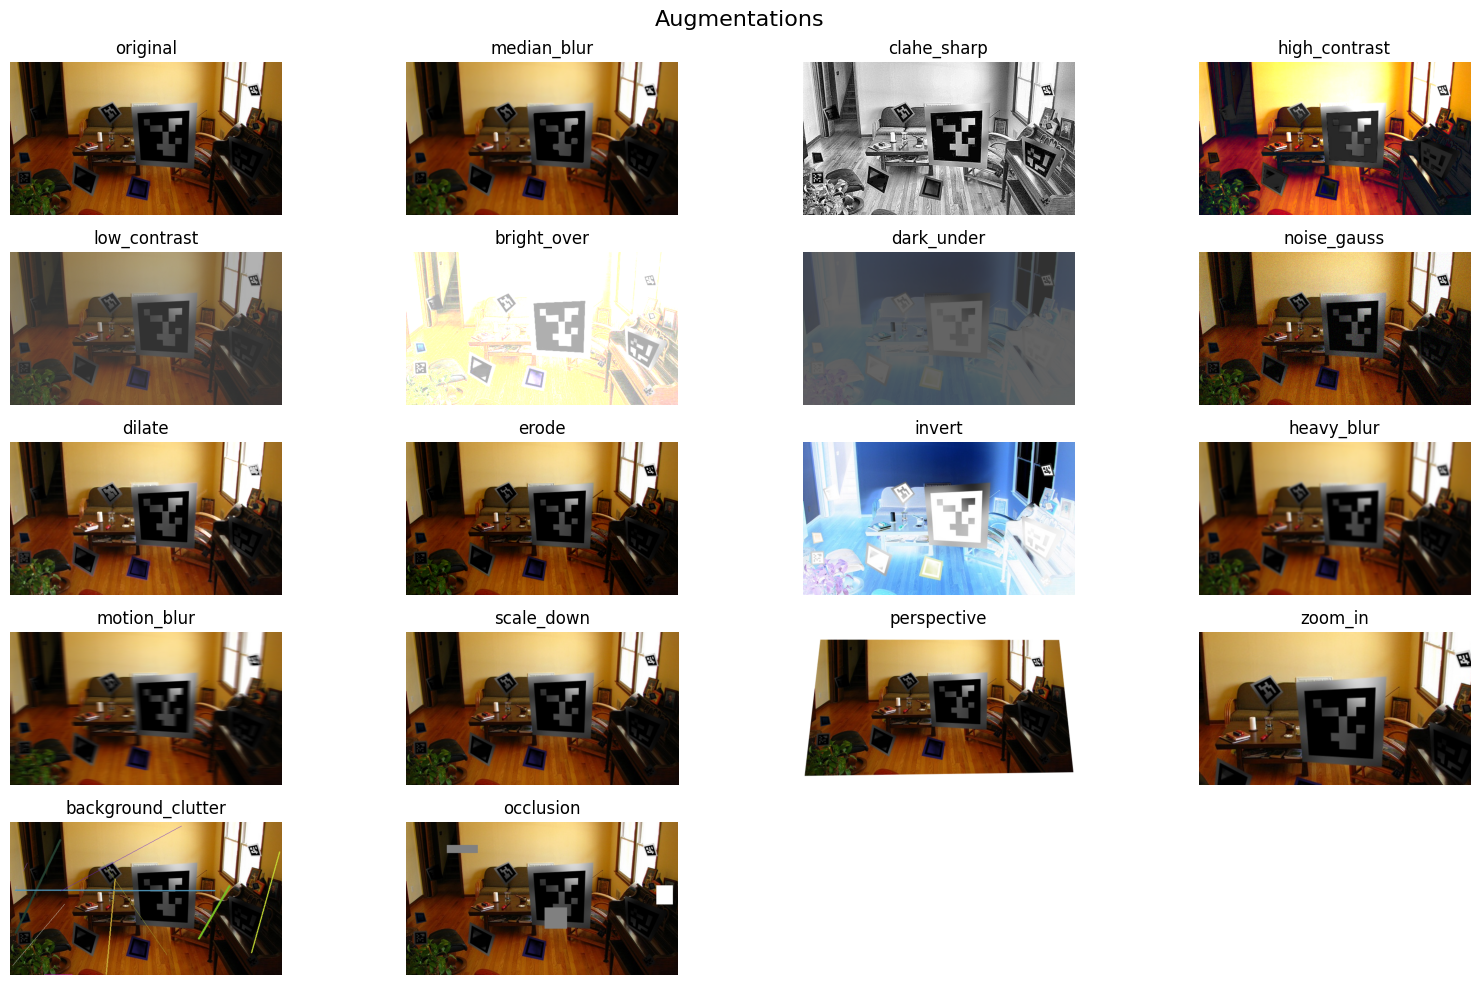

In [2]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def extract_image(v):
    """
    Extract numpy image from unknown dict structure
    """

    if isinstance(v, np.ndarray):
        return v

    if isinstance(v, dict):
        # thử các key phổ biến nhất
        for key in ["image", "img", "output", "result", "data"]:
            if key in v and isinstance(v[key], np.ndarray):
                return v[key]

        # fallback: tìm value đầu tiên là image
        for val in v.values():
            if isinstance(val, np.ndarray):
                return val

    return None

def visualize_augmentations(aug_dict, cols=4, figsize=(16, 10), title="Augmentations"):
    keys = list(aug_dict.keys())
    n = len(keys)
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=figsize)
    plt.suptitle(title, fontsize=16)

    for i, k in enumerate(keys):
        raw = aug_dict[k]
        img = extract_image(raw)

        if img is None:
            print(f"[SKIP] {k}: cannot extract image")
            continue

        # convert BGR → RGB nếu cần
        if len(img.shape) == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
        plt.title(k)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    
from src.preprocess import generate_augmented_images

img = cv2.imread("data/aruco_data/train/000000002270.jpg")
aug_dict = generate_augmented_images(img)

visualize_augmentations(aug_dict, cols=4)